📘 Notebook 2: Regression and Predictive Uncertainty

MATH 6388 - Statistical and Machine Learning

Instructor: Farhad Pourkamali

### Linear model for regression

* Given the training data set $D=\{(\mathbf{x}_n,y_n)\}_{n=1}^N$ and a data point $\mathbf{x}\in\mathbb{R}^D$, the linear regression model takes the form

$$f(\mathbf{x};w_0,\mathbf{w})=w_0+w_1x_1+w_2x_2+\ldots+w_Dx_D=w_0+\mathbf{w}^T\mathbf{x}$$
    
> **Note:** We have dropped the sample index $n$ and write $\mathbf{x}$ for a generic input. The subscripts $1,\ldots,D$ in $x_1,\ldots,x_D$ now index the **features (dimensions)** of $\mathbf{x}$, not the training samples.

* A more compact representation by defining $\mathbf{x}=[\color{red}{x_0=1},x_1,\ldots,x_D]$ and $\mathbf{w}=[w_0,w_1,\ldots,w_D]$ in $\mathbb{R}^{D+1}$

$$f(\mathbf{x};\mathbf{w})=\mathbf{w}^T\mathbf{x}=\langle \mathbf{w}, \mathbf{x}\rangle$$

### Building loss function with the likelihood approach


- Let us assume the output distribution is Gaussian or normal with the mean value of $f(\mathbf{x};\mathbf{w})$ and fixed variance $\sigma^2$

$$
p(y|\mathbf{x},\mathbf{w})
=N\big(y|f(\mathbf{x};\mathbf{w}), \sigma^2\big)
=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{1}{2\sigma^2}(y-f(\mathbf{x};\mathbf{w}))^2\right)
$$

- Thus, we can find the Negative Log Likelihood (NLL) function

$$
\begin{aligned}
NLL(\mathbf{w})
&= -\sum_{n=1}^N \log p(y_n|\mathbf{x}_n,\mathbf{w}) \\[4pt]
&= -\sum_{n=1}^N
\left[
\log\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right)
+
\log\left(
\exp\left(
-\frac{1}{2\sigma^2}
(y_n-f(\mathbf{x}_n;\mathbf{w}))^2
\right)
\right)
\right] \\[4pt]
&= -\sum_{n=1}^N
\left[
-\frac{1}{2}\log(2\pi\sigma^2)
-\frac{1}{2\sigma^2}
(y_n-f(\mathbf{x}_n;\mathbf{w}))^2
\right] \\[4pt]
&= \frac{N}{2}\log(2\pi\sigma^2)
+\frac{1}{2\sigma^2}
\sum_{n=1}^N
\big(y_n-f(\mathbf{x}_n;\mathbf{w})\big)^2.
\end{aligned}
$$

- Here, we used $\log(1/a)=-\log(a)$, $\log(\sqrt{a})=\frac{1}{2}\log(a)$, and $\log(\exp(z))=z$.

### Compact representation of loss function

* The NLL is equal (up to irrelevant constants) to the residual sum of squares (RSS)

$$\text{RSS}(\mathbf{w})=\frac{1}{2}\sum_{n=1}^N\big(y_n-\langle \mathbf{w},\mathbf{x}_n\rangle\big)^2=\frac{1}{2}\|\mathbf{y}-\mathbf{X}\mathbf{w}\|_2^2$$

where we have

$$\mathbf{y}=\begin{bmatrix}y_1\\y_2\\ \vdots\\y_N\end{bmatrix}\in\mathbb{R}^N, \;\mathbf{X}=\begin{bmatrix}\rule[.5ex]{1em}{0.4pt}\mathbf{x}_1^T \rule[.5ex]{1em}{0.4pt}\\ \vdots\\\rule[.5ex]{1em}{0.4pt}\mathbf{x}_N^T \rule[.5ex]{1em}{0.4pt}\end{bmatrix}\in\mathbb{R}^{N\times (D+1)}, \mathbf{w}=\begin{bmatrix}
w_0\\w_1\\ \vdots \\w_{D}\end{bmatrix}\in\mathbb{R}^{D+1}$$

* Optimization problem for model fitting

$$\underset{\mathbf{w}\in\mathbb{R}^{D+1}}{\operatorname{argmin}} \text{RSS}(\mathbf{w})$$


* The big picture

<img src="https://github.com/farhad-pourkamali/MATH6388/blob/main/images/ml_general.png?raw=true\" width=650>


* The RSS loss function is derived under the assumption of homoscedastic noise, meaning that the variance of the noise is uniform across the input space.
    * This uniformity implies that the error distribution remains constant, regardless of the specific input values.
* However, in many real-world scenarios, the noise can be heteroscedastic, meaning it varies with different inputs. When the noise is input-dependent, using the RSS loss function becomes suboptimal, as it fails to account for the varying levels of uncertainty associated with different inputs.


### Two useful gradient identities

Two useful identities that frequently appear when optimizing linear regression models are

$$
\nabla_{\mathbf{w}}(\mathbf{w}^T\mathbf{x})=\mathbf{x},
\qquad
\nabla_{\mathbf{w}}(\mathbf{w}^T\mathbf{A}\mathbf{w})
=(\mathbf{A}+\mathbf{A}^T)\mathbf{w},
$$

> **Special case:** If $\mathbf{A}$ is symmetric, then $\mathbf{A}=\mathbf{A}^T$, so
>
> $$
> \nabla_{\mathbf{w}}(\mathbf{w}^T\mathbf{A}\mathbf{w})
> =
> 2\mathbf{A}\mathbf{w}.
> $$

where $\mathbf{x}$ and $\mathbf{A}$ are fixed.

#### Why does the first identity hold?

Consider the 2D case

$$
\mathbf{w}=
\begin{bmatrix}
w_1\\
w_2
\end{bmatrix},
\qquad
\mathbf{x}=
\begin{bmatrix}
x_1\\
x_2
\end{bmatrix}.
$$

Then

$$
\mathbf{w}^T\mathbf{x}
=
w_1x_1+w_2x_2.
$$

Taking derivatives with respect to the components of $\mathbf{w}$ gives

$$
\nabla_{\mathbf{w}}(\mathbf{w}^T\mathbf{x})
=
\begin{bmatrix}
\frac{\partial}{\partial w_1}(w_1x_1+w_2x_2)\\
\frac{\partial}{\partial w_2}(w_1x_1+w_2x_2)
\end{bmatrix}
=
\begin{bmatrix}
x_1\\
x_2
\end{bmatrix}
=
\mathbf{x}.
$$




✏️ Problem 2.1: Why does the second identity hold? Complete the following.

For the 2D case, let

$$
\mathbf{A}
=
\begin{bmatrix}
a & b\\
c & d
\end{bmatrix}.
$$

Expanding the quadratic form gives

$$
\begin{align}
\mathbf{w}^T\mathbf{A}\mathbf{w} &=
\end{align}
$$

Therefore,

$$
\nabla_{\mathbf{w}}(\mathbf{w}^T\mathbf{A}\mathbf{w})
=
$$

Notice that

$$
\mathbf{A}+\mathbf{A}^T
=
$$

Therefore,

$$
\nabla_{\mathbf{w}}(\mathbf{w}^T\mathbf{A}\mathbf{w})
=
$$


### Gradient of RSS

* Let us revisit the loss function for linear regression

$$\begin{align}\text{RSS}(\mathbf{w})=& \frac{1}{2}\|\mathbf{X}\mathbf{w}-\mathbf{y}\|_2^2=\frac{1}{2}(\mathbf{X}\mathbf{w}-\mathbf{y})^T(\mathbf{X}\mathbf{w}-\mathbf{y})\\
=&\frac{1}{2}(\mathbf{w}^T\mathbf{X}^T-\mathbf{y}^T)(\mathbf{X}\mathbf{w}-\mathbf{y})\\=&\frac{1}{2}(\mathbf{w}^T\mathbf{X}^T\mathbf{X}\mathbf{w}-2\langle\mathbf{X}^T\mathbf{y},\mathbf{w}\rangle+\mathbf{y}^T\mathbf{y})\end{align}$$

* Hence

$$\nabla \text{RSS}(\mathbf{w})=\frac{1}{2}(2\mathbf{X}^T\mathbf{X}\mathbf{w}-2\mathbf{X}^T\mathbf{y})=\mathbf{X}^T(\mathbf{X}\mathbf{w}-\mathbf{y})$$

### Ordinary least squares (OLS)

- To find the minimizer of the RSS, we set the gradient equal to zero:

$$
\nabla_{\mathbf{w}}\text{RSS}(\mathbf{w})
=
\mathbf{X}^T(\mathbf{X}\mathbf{w}-\mathbf{y})
=
\mathbf{0}.
$$

- Therefore,

$$
\mathbf{X}^T\mathbf{X}\mathbf{w}
=
\mathbf{X}^T\mathbf{y}.
$$

These equations are called the **normal equations**.

- If $\mathbf{X}$ has full column rank, then $\mathbf{X}^T\mathbf{X}$ is invertible and the unique solution is

$$
\hat{\mathbf{w}}
=
(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}.
$$

- In this case,

$$
\mathbf{X}^{\dagger}
=
(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T
$$

is the pseudoinverse of $\mathbf{X}$, so we can also write

$$
\hat{\mathbf{w}}
=
\mathbf{X}^{\dagger}\mathbf{y}.
$$

- Since RSS is a convex quadratic function of $\mathbf{w}$, if $\mathbf{X}$ has full column rank, this solution is the **unique global minimum**.

### Algorithmic issues

- In practice, we should generally **not explicitly compute**
  $(\mathbf{X}^T\mathbf{X})^{-1}$ because of numerical stability issues.

- $\mathbf{X}^T\mathbf{X}$ may be ill-conditioned, especially when some features are highly correlated.

- Solving the resulting $D\times D$ linear system has computational cost on the order of $O(D^3)$.

    - Doubling the number of features can therefore increase this part of the computational cost by roughly a factor of $8$.

- When the number of training samples $N$ is very large, the design matrix

$$
\mathbf{X}\in\mathbb{R}^{N\times D}
$$

can itself be extremely large and may be difficult or impossible to store entirely in memory.

### An alternative: gradient descent

- Instead of computing the closed-form OLS solution, we can use **gradient descent**, which we introduced earlier.

- Recall that

$$
\nabla_{\mathbf{w}}\text{RSS}(\mathbf{w})
=
\mathbf{X}^T(\mathbf{X}\mathbf{w}-\mathbf{y}).
$$

- Starting from an initial $\mathbf{w}^{(0)}$, gradient descent repeatedly updates the parameters as

$$
\mathbf{w}^{(t+1)}
=
\mathbf{w}^{(t)}
-
\eta\nabla_{\mathbf{w}}\text{RSS}(\mathbf{w}^{(t)}),
$$

where $\eta>0$ is the learning rate.

- For very large datasets, we can go one step further and use **stochastic or mini-batch gradient descent**, where each update uses only a small subset of the training data.

<img src="https://github.com/farhad-pourkamali/MATH6388Updated/blob/main/Images/mini-batch.png?raw=true\" width=650>

### PyTorch example

In [4]:
import numpy as np

rng = np.random.default_rng(seed=42)
N = 200  # number of instances
X = 2 * rng.random((N, 1))  # column vector
y = 4 + 3 * X + 0.5*rng.standard_normal((N, 1))  # column vector

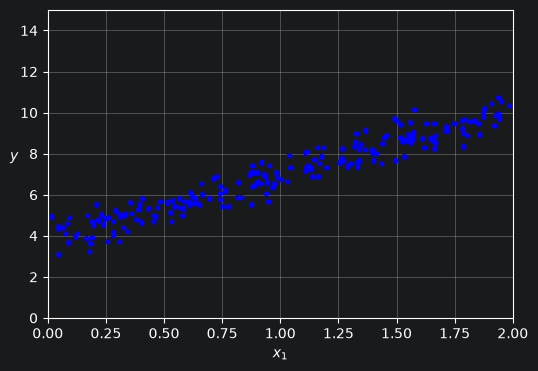

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()

plt.show()

In [6]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # add x0 = 1 to each instance

print(X_b.shape)

(200, 2)


In [7]:
X_b[:5] # 1st column of all 1's

array([[1.        , 1.5479121 ],
       [1.        , 0.87775688],
       [1.        , 1.71719584],
       [1.        , 1.39473606],
       [1.        , 0.1883547 ]])

In [8]:
# normal equation

w_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print(w_best)

[[3.84542069]
 [3.16480229]]


In [9]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)  # add x0 = 1 to each instance
y_predict = X_new_b @ w_best
print(y_predict)

[[ 3.84542069]
 [10.17502527]]


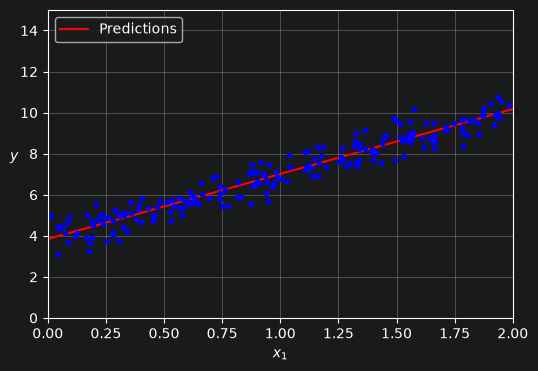

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")

plt.show()

### Batch Gradient Descent

- In batch gradient descent, we use the entire training dataset to compute the gradient at every iteration. For linear regression with the residual sum of squares (RSS), the parameter update is

$$
\mathbf{w}^{(t+1)}
=
\mathbf{w}^{(t)}
-
\eta\nabla_{\mathbf{w}}\text{RSS}(\mathbf{w}^{(t)}),
$$

- For the mean squared error loss function,

$$
\mathrm{MSE}(\mathbf{w})
=
\frac{1}{N}
\left\|
\mathbf{X}\mathbf{w}-\mathbf{y}
\right\|_2^2
$$

and

$$
\nabla_{\mathbf{w}}\mathrm{MSE}(\mathbf{w})
=
\frac{2}{N}
\mathbf{X}^{T}
\left(
\mathbf{X}\mathbf{w}-\mathbf{y}
\right)
$$

- At each epoch, all N training observations are used to compute one gradient and one parameter update.

- The learning rate $\eta$ controls the size of each step. A learning rate that is too small leads to slow convergence, while a learning rate that is too large can cause the algorithm to overshoot the minimum or even diverge.

In [11]:
eta = 0.1  # learning rate
n_epochs = 100
N = len(X_b)  # number of instances

rng = np.random.default_rng(seed=42)
w = rng.standard_normal((2, 1))  # randomly initialized model parameters

for epoch in range(n_epochs):
    gradients = 2 / N * X_b.T @ (X_b @ w - y)
    w = w - eta * gradients

print(w)

[[3.84789069]
 [3.16267144]]


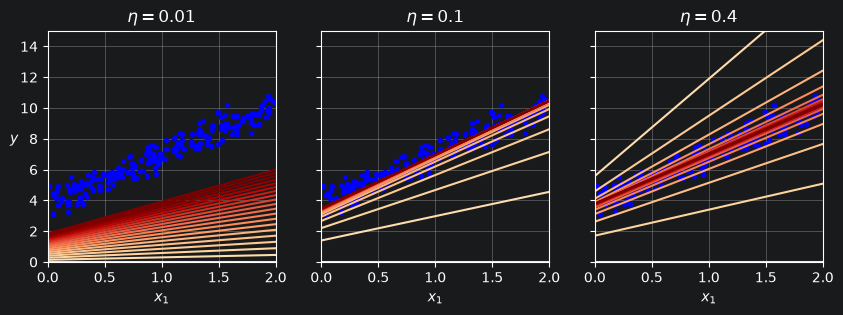

In [12]:
import matplotlib as mpl

def plot_gradient_descent(w, eta):
    N = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 100
    n_shown = 20
    w_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ w
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / N * X_b.T @ (X_b @ w - y)
        w = w - eta * gradients
        w_path.append(w)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return w_path

w = np.zeros((2,1)) # initial value

plt.figure(figsize=(10, 3))
plt.subplot(131)
plot_gradient_descent(w, eta=0.01)
plt.ylabel("$y$", rotation=0)

plt.subplot(132)
plot_gradient_descent(w, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])

plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(w, eta=0.4)

plt.show()

### Mini-batch gradient descent

- Unlike batch gradient descent, the parameters are updated after every mini-batch, rather than once per epoch.

- The data are typically shuffled at the beginning of each epoch so that the mini-batches change from one epoch to the next.

In [13]:
eta = 0.1
n_epochs = 100
batch_size = 20

N = len(X_b)

rng = np.random.default_rng(seed=42)
w = rng.standard_normal((2, 1))


for epoch in range(n_epochs):

    # Shuffle the data at the beginning of each epoch
    indices = rng.permutation(N)
    X_shuffled = X_b[indices]
    y_shuffled = y[indices]

    # Mini-batch gradient descent
    for start in range(0, N, batch_size):

        X_batch = X_shuffled[start:start + batch_size]
        y_batch = y_shuffled[start:start + batch_size]

        # Actual batch size (important for the last batch)
        m = len(X_batch)

        # Gradient using only the current mini-batch
        gradients = 2 / m * X_batch.T @ (X_batch @ w - y_batch)

        w = w - eta * gradients


print(w)

[[3.83568463]
 [3.14722266]]


In [14]:
# Understanding code above
list(range(0, N, batch_size))

[0, 20, 40, 60, 80, 100, 120, 140, 160, 180]

### Linear Regression Using PyTorch's High-Level API

So far, we have implemented linear regression by explicitly computing the gradient. PyTorch provides higher-level tools that automate these steps while following the same optimization procedure.

- **`nn.Linear`** represents the linear model

  $$
  \hat{y} = \mathbf{w}^T\mathbf{x} + b
  $$

  and automatically creates the trainable parameters $\mathbf{w}$ and $b$.

- We still follow the same training loop:

  $$
  \text{prediction}
  \rightarrow
  \text{loss}
  \rightarrow
  \text{gradients}
  \rightarrow
  \text{parameter update}
  $$

- The key advantage is that **we no longer need to derive and implement the gradient manually**.

> **Note:** The mathematics has not changed. PyTorch simply handles parameter management and gradient computation for us.

<img src="https://github.com/farhad-pourkamali/MATH6388Updated/blob/main/Images/nnlinear.png?raw=true\" width=600>


In [15]:
import torch
import torch.nn as nn

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [16]:
# Load the California housing dataset

housing = fetch_california_housing(as_frame=True)

housing.data.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [17]:
housing.target.head()


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    housing.data.to_numpy(),
    housing.target.to_numpy(),
    random_state=42)

In [19]:
# Convert NumPy arrays to PyTorch tensors

X_train = torch.as_tensor(X_train, dtype=torch.float32)
X_test = torch.as_tensor(X_test, dtype=torch.float32)

y_train = torch.as_tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.as_tensor(y_test, dtype=torch.float32).view(-1, 1)

In [20]:
# Standardize the input features using the training-set statistics

means = X_train.mean(dim=0, keepdim=True)
stds = X_train.std(dim=0, keepdim=True)

X_train = (X_train - means) / stds
X_test = (X_test - means) / stds

In [21]:
# Number of input features

n_features = X_train.shape[1]

print(n_features)

8


In [22]:
# Define a linear regression model

torch.manual_seed(42)

model = nn.Linear(
    in_features=n_features,
    out_features=1
)

In [23]:
# Inspect the model parameters

print("Bias:")
print(model.bias)

print("\nWeights:")
print(model.weight)

Bias:
Parameter containing:
tensor([0.3117], requires_grad=True)

Weights:
Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)


In [24]:
# Another way to inspect all trainable parameters

for param in model.parameters():
    print(param)

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)
Parameter containing:
tensor([0.3117], requires_grad=True)


In [25]:
# Count all trainable parameters

num_params = sum(param.numel() for param in model.parameters())

print(num_params)

9


In [26]:
# Define the loss function and optimizer

learning_rate = 0.01

mse = nn.MSELoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=learning_rate
)

In [27]:
# Batch gradient descent training

n_epochs = 1000


for epoch in range(n_epochs):

    # Forward pass
    y_pred = model(X_train)

    # Compute the loss
    loss = mse(y_pred, y_train)

    # Compute gradients using autograd
    loss.backward()

    # Update the model parameters
    optimizer.step()

    # Reset gradients before the next iteration
    optimizer.zero_grad()

    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch {epoch + 1}/{n_epochs}, "
            f"Training Loss: {loss.item():.4f}"
        )

Epoch 100/1000, Training Loss: 0.6695
Epoch 200/1000, Training Loss: 0.5852
Epoch 300/1000, Training Loss: 0.5682
Epoch 400/1000, Training Loss: 0.5565
Epoch 500/1000, Training Loss: 0.5477
Epoch 600/1000, Training Loss: 0.5412
Epoch 700/1000, Training Loss: 0.5363
Epoch 800/1000, Training Loss: 0.5326
Epoch 900/1000, Training Loss: 0.5299
Epoch 1000/1000, Training Loss: 0.5278


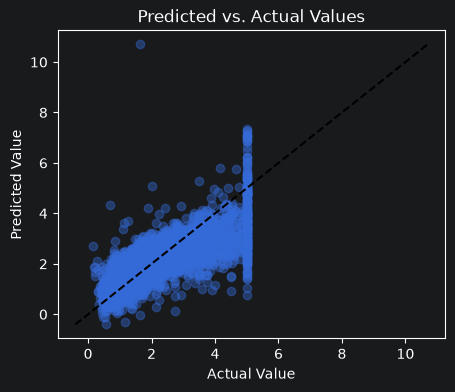

In [28]:
import matplotlib.pyplot as plt

# Predictions on the test set
with torch.no_grad():
    y_test_pred = model(X_test)

# Convert to NumPy for plotting
y_true = y_test.numpy().flatten()
y_pred = y_test_pred.numpy().flatten()

# Predicted vs. actual
plt.figure(figsize=(5, 4))

plt.scatter(y_true, y_pred, alpha=0.4)

# Perfect prediction line: y = x
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "k--")

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Predicted vs. Actual Values")

plt.show()

Root Mean Squared Error (RMSE) measures the typical magnitude of the prediction errors and is expressed in the same units as the target variable.

$$
\text{RMSE}
=
\left[
\frac{1}{N}
\sum_{i=1}^{N}
\left(\hat{y}_i-y_i\right)^2
\right]^{1/2}
$$

In [29]:
# Test RMSE
rmse = torch.sqrt(torch.mean((y_test_pred - y_test) ** 2))
print("Test RMSE:", rmse.item())

Test RMSE: 0.7384805679321289


### Implementing a Regression Multilayer Perceptron (MLP)


A linear regression model uses a single linear transformation,

$$
\hat{y} = \mathbf{w}^T\mathbf{x} + b,
$$

which limits the model to learning **linear relationships** between the inputs and the output.

- We can make the model more powerful by adding one or more **intermediate layers**, called **hidden layers**.

- Each hidden layer learns a new **representation of the input data** by combining information from the previous layer.

- We also introduce **nonlinear activation functions**, such as ReLU, between the linear layers.

- With hidden layers and nonlinear activation functions, the model can learn much more complex **nonlinear relationships** between the inputs and the output.


<img src="https://github.com/farhad-pourkamali/MATH6388Updated/blob/main/Images/nnarch.png?raw=true\" width=600>


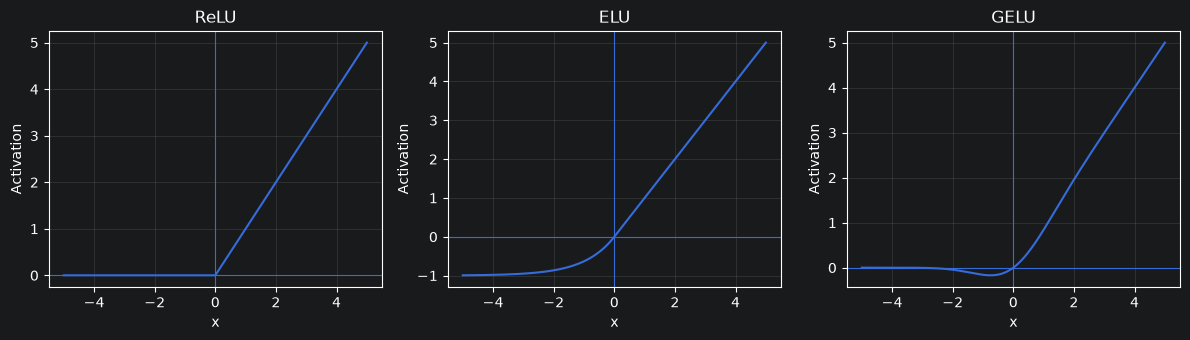

In [30]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Input values
x = torch.linspace(-5, 5, 500)

# Activation functions
y_relu = F.relu(x)
y_elu  = F.elu(x)
y_gelu = F.gelu(x)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(x, y_relu)
axes[0].set_title("ReLU")

axes[1].plot(x, y_elu)
axes[1].set_title("ELU")

axes[2].plot(x, y_gelu)
axes[2].set_title("GELU")

for ax in axes:
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.set_xlabel("x")
    ax.set_ylabel("Activation")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [31]:
myx = torch.linspace(-5, 5, 11)
mygelu = F.gelu(myx)
mygelu
for i, y in enumerate(mygelu):
    print(i, myx[i], y)

0 tensor(-5.) tensor(-1.4901e-06)
1 tensor(-4.) tensor(-0.0001)
2 tensor(-3.) tensor(-0.0040)
3 tensor(-2.) tensor(-0.0455)
4 tensor(-1.) tensor(-0.1587)
5 tensor(0.) tensor(0.)
6 tensor(1.) tensor(0.8413)
7 tensor(2.) tensor(1.9545)
8 tensor(3.) tensor(2.9960)
9 tensor(4.) tensor(3.9999)
10 tensor(5.) tensor(5.0000)


**ReLU (Rectified Linear Unit)**

$$
\text{ReLU}(x)
=
\max(0,x)
$$

**ELU (Exponential Linear Unit)**

$$
\text{ELU}(x)
=
\begin{cases}
x, & x > 0, \\
\alpha(e^x - 1), & x \le 0.
\end{cases}
$$

Typically, $\alpha = 1$.

**GELU (Gaussian Error Linear Unit)**

$$
\text{GELU}(x)
=
x \, \Phi(x)
$$

where $\Phi(x)$ is the cumulative distribution function of the standard normal distribution.

✏️ Problem 2.2: Recall the GELU activation function $g(x)=x\Phi(x)$.

1. Find the derivative $g'(x)$.
2. Evaluate $g'(0)$.
3. Compare the behavior of GELU around $x=0$ with ReLU.



In [50]:
MLP = nn.Sequential(
    nn.Linear(n_features, 32),
    nn.ReLU(),

    nn.Linear(32, 16),
    nn.ReLU(),

    nn.Linear(16, 1)
)

In [59]:
MLP[0].weight.shape

torch.Size([32, 8])

In [63]:
print(MLP[0].bias.shape)
MLP[0].bias

torch.Size([32])


Parameter containing:
tensor([ 0.2434, -0.1970,  0.2533, -0.1072,  0.1848,  0.2067, -0.2883,  0.0875,
         0.1411, -0.2125,  0.3269,  0.2760,  0.2955, -0.0032, -0.1892, -0.1932,
         0.1250, -0.0702,  0.2810,  0.2961,  0.0273, -0.2894,  0.1403,  0.3164,
        -0.0888, -0.1850, -0.0827,  0.0507, -0.2623,  0.1888,  0.1511, -0.1352],
       requires_grad=True)

In [61]:
for param in MLP.parameters():
    print(param.shape)
    print(param)
    print("---\n")

torch.Size([32, 8])
Parameter containing:
tensor([[ 0.0684, -0.1825,  0.2136,  0.1467, -0.3194, -0.0192, -0.1522, -0.0613],
        [ 0.1969, -0.0380, -0.2455,  0.2487, -0.3232, -0.1214,  0.1362,  0.3125],
        [ 0.3431, -0.0831,  0.1180, -0.3105, -0.0688, -0.1100,  0.1004, -0.2316],
        [ 0.0764,  0.1827,  0.2755, -0.0598,  0.3230, -0.3340, -0.1002,  0.1340],
        [ 0.0907,  0.1665, -0.2346,  0.2177, -0.3318, -0.2424, -0.0240, -0.3435],
        [-0.3361, -0.3139,  0.2843,  0.0776, -0.1128, -0.0145, -0.3082, -0.3339],
        [-0.2466, -0.3420,  0.2326, -0.1237, -0.0954, -0.3045,  0.0586, -0.0530],
        [-0.2407,  0.2267,  0.2980, -0.2520,  0.2003, -0.0574, -0.0033,  0.1505],
        [-0.0645,  0.3004,  0.2175, -0.2295, -0.2152, -0.3503,  0.1132, -0.2659],
        [-0.2963, -0.2266, -0.3495, -0.2879,  0.3154,  0.1975,  0.3133, -0.1715],
        [-0.1450, -0.1241,  0.0069, -0.2538,  0.0518, -0.2266,  0.0559,  0.3239],
        [ 0.0597,  0.2579, -0.2518, -0.0499, -0.2183, -0

In [34]:
# Define the loss function and optimizer

learning_rate = 0.01

mse = nn.MSELoss()

optimizer = torch.optim.SGD(
    MLP.parameters(),
    lr=learning_rate
)

In [55]:
X_train.size()

torch.Size([15480, 8])

In [35]:
# Batch gradient descent training

n_epochs = 1000


for epoch in range(n_epochs):

    # Forward pass
    y_pred = MLP(X_train)

    # Compute the loss
    loss = mse(y_pred, y_train)

    # Compute gradients using autograd
    loss.backward()

    # Update the model parameters
    optimizer.step()

    # Reset gradients before the next iteration
    optimizer.zero_grad()

    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch {epoch + 1}/{n_epochs}, "
            f"Training Loss: {loss.item():.4f}"
        )

Epoch 100/1000, Training Loss: 0.7331
Epoch 200/1000, Training Loss: 0.6139
Epoch 300/1000, Training Loss: 0.5779
Epoch 400/1000, Training Loss: 0.5474
Epoch 500/1000, Training Loss: 0.5218
Epoch 600/1000, Training Loss: 0.5021
Epoch 700/1000, Training Loss: 0.4874
Epoch 800/1000, Training Loss: 0.4764
Epoch 900/1000, Training Loss: 0.4680
Epoch 1000/1000, Training Loss: 0.4612


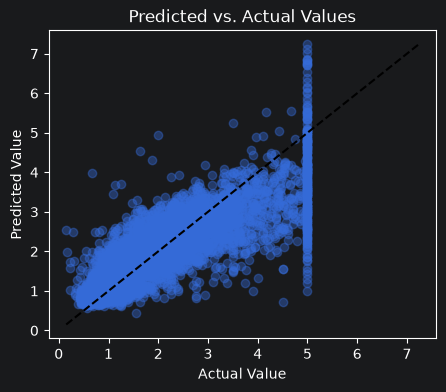

In [36]:
import matplotlib.pyplot as plt

# Predictions on the test set
with torch.no_grad():
    y_test_pred = MLP(X_test)

# Convert to NumPy for plotting
y_true = y_test.numpy().flatten()
y_pred = y_test_pred.numpy().flatten()

# Predicted vs. actual
plt.figure(figsize=(5, 4))

plt.scatter(y_true, y_pred, alpha=0.4)

# Perfect prediction line: y = x
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "k--")

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Predicted vs. Actual Values")

plt.show()

In [37]:
# Test RMSE
rmse = torch.sqrt(torch.mean((y_test_pred - y_test) ** 2))
print("Test RMSE:", rmse.item())

Test RMSE: 0.6803127527236938


✏️ Problem 2.3: Consider the above regression MLP with architecture

$$
D \rightarrow 32 \rightarrow 16 \rightarrow 1,
$$

where the two hidden layers use activation functions $g_1$ and $g_2$, and the output layer has no activation function.

1. Write the complete MLP in **matrix-vector form** using weight matrices
   $\mathbf{W}^{(1)}, \mathbf{W}^{(2)}, \mathbf{W}^{(3)}$
   and bias vectors
   $\mathbf{b}^{(1)}, \mathbf{b}^{(2)}, \mathbf{b}^{(3)}$.

2. Specify the dimensions of each weight matrix and bias vector.

3. Now suppose that we remove the nonlinear activation functions, so that

$$
g_1(z)=g_2(z)=z.
$$

Show that the entire network can be written as a linear regression model.


### Defining a General MLP Class in PyTorch

- Inherit from `nn.Module`: We define our `MLP` class as a subclass of PyTorch's `nn.Module`, which provides the basic functionality needed for neural networks.

- Define the architecture in `__init__`: We create the layers of the network and store them as part of the model. Using a list of `hidden_sizes` makes the class general and reusable for different MLP architectures.

- Define the forward pass: The `forward()` method specifies how the input moves through the network to produce a prediction:
  $$
  \mathbf{x} \longrightarrow \text{hidden layers} \longrightarrow \hat{y}.
  $$

- No need to define the backward pass: We do not manually implement backpropagation. PyTorch's autograd automatically tracks the operations performed during the forward pass and computes the required gradients when we call `loss.backward()`.

> **Note:** `nn.Sequential(*layers)` combines all the layers in the `layers` list into a single neural network that applies them **one after another** in the order they appear.
>
> The `*` is Python's **unpacking operator**. It takes the elements of the list and passes them as separate arguments to `nn.Sequential`.
>
> For example, if
>
> ```python
> layers = [nn.Linear(8, 32), nn.ReLU(), nn.Linear(32, 1)]
> ```
>
> then
>
> ```python
> nn.Sequential(*layers)
> ```
>
> is equivalent to
>
> ```python
> nn.Sequential(
>     nn.Linear(8, 32),
>     nn.ReLU(),
>     nn.Linear(32, 1)
> )
> ```


In [38]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    """
    Multilayer perceptron (MLP) for regression.

    Parameters
    ----------
    input_size : int
        Number of input features.

    hidden_sizes : list
        Number of neurons in each hidden layer.
        For example, [64, 32] creates two hidden layers.
    """

    def __init__(self, input_size, hidden_sizes):
        super().__init__()

        # Define the size of all layers
        sizes = [input_size] + hidden_sizes + [1]

        # Create a list of layers
        layers = []

        for i in range(len(sizes) - 2):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            layers.append(nn.ReLU())

        # Output layer
        layers.append(nn.Linear(sizes[-2], sizes[-1]))

        # Combine all layers
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [39]:
model2 = MLP(
    input_size=n_features,
    hidden_sizes=[64, 32]
)

print(model2)

MLP(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [40]:
# Define the loss function and optimizer

learning_rate = 0.01

mse = nn.MSELoss()

optimizer = torch.optim.SGD(
    model2.parameters(),
    lr=learning_rate
)

In [41]:
# Batch gradient descent training

n_epochs = 1000


for epoch in range(n_epochs):

    # Forward pass
    y_pred = model2(X_train)

    # Compute the loss
    loss = mse(y_pred, y_train)

    # Compute gradients using autograd
    loss.backward()

    # Update the model parameters
    optimizer.step()

    # Reset gradients before the next iteration
    optimizer.zero_grad()

    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch {epoch + 1}/{n_epochs}, "
            f"Training Loss: {loss.item():.4f}"
        )

Epoch 100/1000, Training Loss: 0.6308
Epoch 200/1000, Training Loss: 0.5762
Epoch 300/1000, Training Loss: 0.5390
Epoch 400/1000, Training Loss: 0.5126
Epoch 500/1000, Training Loss: 0.4934
Epoch 600/1000, Training Loss: 0.4788
Epoch 700/1000, Training Loss: 0.4671
Epoch 800/1000, Training Loss: 0.4572
Epoch 900/1000, Training Loss: 0.4486
Epoch 1000/1000, Training Loss: 0.4413


### Beyond Point Predictions: Modeling Predictive Uncertainty

So far, we assumed that the variance $\sigma^2$ is **fixed** and does not depend on the input $\mathbf{x}$.

This is called **homoscedastic noise**:

$$
y = f(\mathbf{x};\mathbf{w}) + \epsilon,
\qquad
\epsilon \sim N(0,\sigma^2).
$$

In many real-world regression problems, however, the amount of noise may change depending on the input.

This is called **heteroscedastic noise**.

Instead of assuming a fixed variance, we allow both the mean and variance to depend on $\mathbf{x}$:

$$
p(y|\mathbf{x},\mathbf{w})
=
N
\left(
y \mid
\mu(\mathbf{x};\mathbf{w}),
\sigma^2(\mathbf{x};\mathbf{w})
\right),
$$

where

$$
\mu(\mathbf{x};\mathbf{w})
=
f_\mu(\mathbf{x};\mathbf{w})
$$

is the predicted mean, and

$$
\sigma^2(\mathbf{x};\mathbf{w})
=
f_{\sigma^2}(\mathbf{x};\mathbf{w})
$$

is the predicted variance.

Therefore, instead of producing only **one output**, the neural network now produces **two outputs**:

$$
\mathbf{x}
\longrightarrow
\text{Neural Network}
\longrightarrow
\begin{cases}
\mu(\mathbf{x}) \\
\sigma^2(\mathbf{x})
\end{cases}
$$

The Gaussian likelihood for one observation is

$$
p(y_n|\mathbf{x}_n,\mathbf{w})
=
\frac{1}
{\sqrt{2\pi\sigma^2(\mathbf{x}_n;\mathbf{w})}}
\exp
\left(
-\frac{
\left(
y_n-\mu(\mathbf{x}_n;\mathbf{w})
\right)^2
}{
2\sigma^2(\mathbf{x}_n;\mathbf{w})
}
\right).
$$

Taking the negative logarithm gives

$$
\begin{aligned}
-\log p(y_n|\mathbf{x}_n,\mathbf{w})
&=
\frac{1}{2}
\log
\left(
2\pi\sigma^2(\mathbf{x}_n;\mathbf{w})
\right)
\\[4pt]
&\quad+
\frac{
\left(
y_n-\mu(\mathbf{x}_n;\mathbf{w})
\right)^2
}{
2\sigma^2(\mathbf{x}_n;\mathbf{w})
}.
\end{aligned}
$$

For all $N$ training observations, the negative log-likelihood becomes

$$
\boxed{
\text{NLL}(\mathbf{w})
=
\frac{1}{N}
\sum_{n=1}^{N}
\left[
\frac{
\left(
y_n-\mu(\mathbf{x}_n;\mathbf{w})
\right)^2
}{
2\sigma^2(\mathbf{x}_n;\mathbf{w})
}
+
\frac{1}{2}
\log
\left(
\sigma^2(\mathbf{x}_n;\mathbf{w})
\right)
\right]
}
$$

where we have dropped the constant term

$$
\frac{1}{2}\log(2\pi),
$$

since it does not affect optimization.

### Why is this different from MSE?

The Gaussian NLL contains two important terms:

$$
\frac{
(y_n-\mu_n)^2
}{
2\sigma_n^2
}
+
\frac{1}{2}\log(\sigma_n^2)
.
$$

- The first term measures the prediction error, similar to MSE, but the error is **scaled by the predicted variance**.

- If the model predicts a **small variance**, it is claiming to be confident, so prediction errors are penalized strongly.

- If the model predicts a **large variance**, the model is expressing more uncertainty, so the same prediction error receives a smaller penalty.

- However, the model cannot simply make $\sigma^2$ arbitrarily large. The term

$$
\frac{1}{2}\log(\sigma^2)
$$

penalizes excessively large uncertainty estimates.

Therefore, the model must learn a balance between

$$
\text{accurate predictions}
\qquad\text{and}\qquad
\text{appropriate uncertainty}.
$$



In [42]:
import torch
import torch.nn as nn


class ProbMLP(nn.Module):
    """
    Probabilistic multilayer perceptron for regression.

    The network predicts both the conditional mean and
    input-dependent variance of a Gaussian distribution.

    Parameters
    ----------
    input_size : int
        Number of input features.

    hidden_sizes : list
        Number of neurons in each hidden layer.
        For example, [64, 32] creates two hidden layers.
    """

    def __init__(self, input_size, hidden_sizes):
        super().__init__()

        # Define the size of all layers
        sizes = [input_size] + hidden_sizes + [2]

        # Create a list of layers
        layers = []

        for i in range(len(sizes) - 2):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            layers.append(nn.ReLU())

        # Two outputs: mean and log-variance
        layers.append(nn.Linear(sizes[-2], sizes[-1]))

        # Combine all layers
        self.network = nn.Sequential(*layers)

    def forward(self, x):

        out = self.network(x)

        mean = out[:, 0:1]
        log_var = out[:, 1:2]

        var = torch.exp(log_var)

        return mean, var

In [43]:
model = ProbMLP(
    input_size=X_train.shape[1],
    hidden_sizes=[32, 16]
)

In [44]:
# Define the loss function and optimizer

learning_rate = 0.01

loss_fn = nn.GaussianNLLLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=learning_rate
)

In [45]:
# Training

n_epochs = 2000

for epoch in range(n_epochs):

    # Forward pass
    mean, var = model(X_train)

    # Compute loss
    loss = loss_fn(mean, y_train, var)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()

    # Update model parameters
    optimizer.step()

    # Print progress
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1:3d} | Loss: {loss.item():.4f}")

Epoch 100 | Loss: 0.7981
Epoch 200 | Loss: 0.5655
Epoch 300 | Loss: 0.4348
Epoch 400 | Loss: 0.3343
Epoch 500 | Loss: 0.2814
Epoch 600 | Loss: 0.2465
Epoch 700 | Loss: 0.2138
Epoch 800 | Loss: 0.1807
Epoch 900 | Loss: 0.1489
Epoch 1000 | Loss: 0.1202
Epoch 1100 | Loss: 0.0961
Epoch 1200 | Loss: 0.0765
Epoch 1300 | Loss: 0.0602
Epoch 1400 | Loss: 0.0460
Epoch 1500 | Loss: 0.0334
Epoch 1600 | Loss: 0.0216
Epoch 1700 | Loss: 0.0103
Epoch 1800 | Loss: -0.0003
Epoch 1900 | Loss: -0.0105
Epoch 2000 | Loss: -0.0201


In [46]:
model.eval()

with torch.no_grad():

    mean_test, var_test = model(X_test)


In [47]:
# Evaluate

rmse = torch.sqrt(torch.mean((y_test - mean_test) ** 2))

print(f"Test RMSE: {rmse.item():.4f}")

Test RMSE: 0.6737


### Constructing a Prediction Interval

Our probabilistic neural network predicts a Gaussian distribution for each input:

$$
y \mid \mathbf{x}
\sim
N
\left(
\mu(\mathbf{x}),
\sigma^2(\mathbf{x})
\right).
$$

For a particular test input $\mathbf{x}_*$, the trained model gives us

$$
\mu_* = \mu(\mathbf{x}_*)
\qquad \text{and} \qquad
\sigma_* = \sqrt{\sigma^2(\mathbf{x}_*)}.
$$

The predicted mean $\mu_*$ is our **point prediction**, while $\sigma_*$ describes the uncertainty around that prediction.

To construct a prediction interval with desired probability $1-\alpha$, we use

$$
\boxed{
\left[
\mu_* - z_{\alpha/2}\sigma_*,
\;
\mu_* + z_{\alpha/2}\sigma_*
\right]
}
$$

where $z_{\alpha/2}$ is the appropriate critical value from the standard normal distribution.

<img src="https://github.com/farhad-pourkamali/MATH6388Updated/blob/main/Images/zscore.png?raw=true\" width=400>

For example, for a 95% prediction interval,

$$
1-\alpha = 0.95
\quad\Longrightarrow\quad
\alpha = 0.05,
$$

and

$$
z_{\alpha/2}
=
\Phi^{-1}(1-\alpha/2)
=
\Phi^{-1}(0.975)
\approx 1.96.
$$

Therefore,

$$
\text{95% Prediction Interval}
=
\mu_* \pm 1.96\sigma_*.
$$

> **Key idea:** Unlike MSE regression, which gives us only the point prediction $\mu_*$, the probabilistic model also gives us $\sigma_*$, allowing the prediction interval to be **different for each input**.

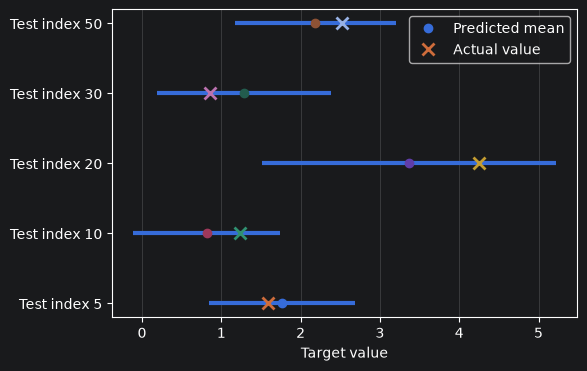

In [48]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# Select test points
indices = [5, 10, 20, 30, 50]

# Desired probability
confidence_level = 0.95

# Critical value
alpha = 1 - confidence_level
z = norm.ppf(1 - alpha / 2)

# Select test inputs and outputs
X_selected = X_test[indices]
y_selected = y_test[indices]

# Predict mean and variance
model.eval()

with torch.no_grad():
    mean, var = model(X_selected)

std = torch.sqrt(var)

# Construct prediction intervals
lower = mean - z * std
upper = mean + z * std

# Convert to NumPy for plotting
mean = mean.squeeze().numpy()
lower = lower.squeeze().numpy()
upper = upper.squeeze().numpy()
y_selected = y_selected.squeeze().numpy()

# Plot
plt.figure(figsize=(6, 4))

positions = range(len(indices))

for i in positions:

    # Prediction interval
    plt.hlines(
        y=i,
        xmin=lower[i],
        xmax=upper[i],
        linewidth=3
    )

    # Predicted mean
    plt.plot(
        mean[i],
        i,
        "o",
        label="Predicted mean" if i == 0 else ""
    )

    # Actual test value
    plt.plot(
        y_selected[i],
        i,
        "x",
        markersize=9,
        markeredgewidth=2,
        label="Actual value" if i == 0 else ""
    )

plt.yticks(
    positions,
    [f"Test index {i}" for i in indices]
)

plt.xlabel("Target value")

plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.show()

✏️ Problem 2.4: Implementing the Gaussian NLL Loss

Throughout this section, we used PyTorch's built-in `nn.GaussianNLLLoss()` to train our probabilistic neural network. In this problem, you will implement the Gaussian negative log-likelihood (NLL) yourself and verify your implementation.

#### Part (a): Implement the loss function

Using our previous derivation of the Gaussian NLL, define your own function

```python
def gaussian_nll(y, mean, var):
    # Your code here
```

that computes the **average Gaussian negative log-likelihood** over a batch of observations.

You may refer to the PyTorch documentation for `nn.GaussianNLLLoss` when implementing your function: https://docs.pytorch.org/docs/2.13/generated/torch.nn.GaussianNLLLoss.html

#### Part (b): Verify your implementation

Use the trained `ProbMLP` model to obtain the predicted means and variances for the **test data**.

Then compute the test loss in two different ways:

1. Using your own `gaussian_nll()` function.
2. Using PyTorch's `nn.GaussianNLLLoss()`.

Print both loss values and compare them. Do the two implementations produce approximately the same test loss?

### 📚 Further Reading

The heteroscedastic Gaussian model provides a simple and useful way to move from **point predictions** to **predictive distributions**. However, there are important limitations and extensions worth exploring.

- **Pitfalls of heteroscedastic Gaussian regression.**  
  When training with Gaussian NLL, the predicted variance $\sigma^2(\mathbf{x})$ directly changes how strongly prediction errors are penalized. In some situations, this interaction can lead to poor estimates of the mean and variance and overly large uncertainty estimates. Seitzer et al. study this behavior and propose the $\beta$-NLL loss as an alternative.

  **Seitzer et al. (2022), _On the Pitfalls of Heteroscedastic Uncertainty Estimation with Probabilistic Neural Networks_**  
  https://arxiv.org/abs/2203.09168

- **Moving beyond the Gaussian assumption.**  
  We do not necessarily have to assume that the predictive distribution is Gaussian. A more flexible alternative is the Student's $t$-distribution:

  $$
  y|\mathbf{x}
  \sim
  t\left(
  \mu(\mathbf{x}),
  s(\mathbf{x}),
  \nu(\mathbf{x})
  \right),
  $$

  where the neural network learns three input-dependent quantities:

  $$
  \underbrace{\mu(\mathbf{x})}_{\text{location}},
  \qquad
  \underbrace{s(\mathbf{x})}_{\text{scale}},
  \qquad
  \underbrace{\nu(\mathbf{x})}_{\text{degrees of freedom}}.
  $$

  The degrees-of-freedom parameter $\nu(\mathbf{x})$ controls the **tail behavior** of the predictive distribution, allowing the model to adapt between heavier-tailed and approximately Gaussian predictive distributions.

  **Pourkamali-Anaraki (2026), _Probabilistic Neural Networks (PNNs) with t-Distributed Outputs: Adaptive Prediction Intervals Beyond Gaussian Assumptions_**  
  https://arxiv.org/abs/2503.12354

> **Takeaway:** Predictive uncertainty depends not only on predicting a variance, but also on choosing an appropriate **predictive distribution and loss function**.